In [9]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Cài đặt giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 10)

# --- ĐỊNH NGHĨA 11 NHÃN CHUẨN ---
CLASS_NAMES = [
    'Streaming', 'VPN-VoIP', 'VPN-chat', 'VPN-email', 'VPN-file_transfer',
    'VPN-p2p', 'VPN-streaming', 'VoIP', 'chat', 'email', 'file_transfer'
]

# BỘ LỌC RULE-BASED (BẢN FINAL DEMO)
SNI_RULES_ADVANCED = {
    'mail.google.com': 'email', 'mail-attachment.googleusercontent.com': 'email',
    'ci3.googleusercontent.com': 'email', 'lh3.googleusercontent.com': 'email',
    'lh4.googleusercontent.com': 'email', 'lh5.googleusercontent.com': 'email',
    'lh6.googleusercontent.com': 'email', 'inbox.google.com': 'email',
    'gmail.com': 'email', 'outlook.live.com': 'email', 'outlook.office.com': 'email',
    'outlook.office365.com': 'email', 'smtp': 'email', 'imap': 'email', 'pop3': 'email',
    'googlevideo.com': 'Streaming', 'youtube.com': 'Streaming', 'ytimg.com': 'Streaming',
    'video.xx.fbcdn.net': 'Streaming', 'nflxvideo.net': 'Streaming', 'netflix.com': 'Streaming',
    'vimeocdn.com': 'Streaming', 'ttvnw.net': 'Streaming',
    'drive.google.com': 'file_transfer', 'docs.google.com': 'file_transfer',
    'drive-thirdparty.googleusercontent.com': 'file_transfer', 'clients6.google.com': 'file_transfer',
    'dropbox.com': 'file_transfer', 'onedrive.live.com': 'file_transfer', 'fbsbx.com': 'file_transfer',
    'sharepoint.com': 'file_transfer', 'mediafire.com': 'file_transfer', 'mega.nz': 'file_transfer',
    'opentrackr': 'p2p', 'openbittorrent': 'p2p', 'tracker': 'p2p', 'torrent': 'p2p',
    'announce': 'p2p', 'dht.transmissionbt.com': 'p2p',
}

In [10]:
def load_ai_model(model_path):
    print("[AI] Đang nạp cấu trúc ResNet-18 tùy chỉnh...")
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, 11)
    )
    checkpoint = torch.load(model_path, map_location=torch.device('cpu'))
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    model.eval()
    print("[AI] Lõi AI đã sẵn sàng!")
    return model

def features_to_tensor(features_list):
    features_81 = list(features_list)
    if len(features_81) < 81:
        features_81.extend([0.0] * (81 - len(features_81)))
    elif len(features_81) > 81:
        features_81 = features_81[:81]
    
    arr = np.array(features_81, dtype=np.float32)
    arr_min, arr_max = np.min(arr), np.max(arr)
    if arr_max - arr_min != 0:
        arr_normalized = (arr - arr_min) / (arr_max - arr_min)
    else:
        arr_normalized = arr - arr_min
        
    image_9x9 = arr_normalized.reshape(9, 9)
    image_rgb = np.stack([image_9x9, image_9x9, image_9x9], axis=0)
    tensor_input = torch.tensor(np.expand_dims(image_rgb, axis=0), dtype=torch.float32)
    return tensor_input

def hybrid_predict_advanced(model, tensor_input, sni_domain, protocol, dst_port=0):
    domain_lower = str(sni_domain).lower()

    for key, label in SNI_RULES_ADVANCED.items():
        if key in domain_lower:
            return label

    chat_voip_apps = [
        'zalo', 'zadn.vn', 'zalocdn', 'telegram', 't.me', 'messenger',
        'meet.google', 'hangouts', 'teams', 'discord', 'zoom', 'skype', 'webrtc', 'cloudapp.azure.com'
    ]
    if any(app in domain_lower for app in chat_voip_apps):
        if protocol == 17:  
            return "VoIP"
        else:               
            return "chat"
            
    if 'tiktok' in domain_lower:
        return "Streaming" if protocol == 17 else "chat"

    if protocol == 17 and (dst_port == 3478 or dst_port > 10000):
        return "VoIP"

    with torch.no_grad():
        output = model(tensor_input)
        idx = torch.argmax(output, dim=1).item()
        pred = CLASS_NAMES[idx]

    if domain_lower not in ['', 'none', 'unknown', 'nan']:
        if pred.startswith('VPN-'):
            return pred.replace('VPN-', '') 
        return pred

    return pred

In [11]:
# THAY ĐỔI ĐƯỜNG DẪN BÊN DƯỚI CHO ĐÚNG VỚI MÁY CỦA BẠN NẾU CẦN
model_path = "model_final_Application_Label.pth" 
model = load_ai_model(model_path)

[AI] Đang nạp cấu trúc ResNet-18 tùy chỉnh...
[AI] Lõi AI đã sẵn sàng!


In [12]:
base_path = "csv" # Thư mục chứa 11 file csv

# Cấu hình map 11 file với đúng nhãn thực tế
files_mapping = {
    "01_streaming.csv": "Streaming",
    "02_file_transfer.csv": "file_transfer",
    "03_email.csv": "email",
    "04_VoIP.csv": "VoIP",
    "05_chat.csv": "chat",
    "06_VPN-p2p.csv": "VPN-p2p",
    "07_VPN-streaming.csv": "VPN-streaming",
    "08_VPN-file transfer.csv": "VPN-file_transfer", 
    "09_VPN-email.csv": "VPN-email",
    "10_VPN-chat.csv": "VPN-chat",
    "11_VPN-VoIP.csv": "VPN-VoIP"
}

dataframes = []

for filename, true_label in files_mapping.items():
    file_path = os.path.join(base_path, filename)
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        
        if 'AI_Prediction' in df.columns:
            df = df[df['AI_Prediction'] != 'Unknown']
            df = df[df['AI_Prediction'] != 'Error']
        
        y_pred_new = []
        print(f"Đang đánh giá file: {filename} (True Label: {true_label})...")
        
        for index, row in df.iterrows():
            domain = row.get('Destination / Websites', 'Unknown')
            protocol = row.get('Protocol', 6) if 'Protocol' in df.columns else row.get('protocol', 6)
            dst_port = row.get('Dst Port', 0) if 'Dst Port' in df.columns else row.get('dst_port', 0)
            
            cols_to_drop = ['ID', 'Timestamp', 'Destination / Websites', 'AI_Prediction', 'True_Label', 'Flow ID', 'Src IP', 'Dst IP']
            numeric_cols = [c for c in df.columns if c not in cols_to_drop and df[c].dtype != 'object']
            
            features = row[numeric_cols].tolist()
            tensor_data = features_to_tensor(features)
            
            new_pred = hybrid_predict_advanced(model, tensor_data, domain, protocol, dst_port)
            y_pred_new.append(new_pred)
        
        df['AI_Prediction_NEW'] = y_pred_new
        df['True_Label'] = true_label
        dataframes.append(df)
        print(f"✅ Hoàn tất file: {filename} ({len(df)} luồng)")
    else:
        print(f"⚠️ Không tìm thấy file: {file_path}")

if dataframes:
    df_eval = pd.concat(dataframes, ignore_index=True)
    print(f"\n=> TỔNG SỐ LUỒNG DỮ LIỆU ĐÁNH GIÁ THỰC TẾ: {len(df_eval)}")
    
    y_true = df_eval['True_Label']
    y_pred = df_eval['AI_Prediction_NEW']
else:
    print("Không có dữ liệu để đánh giá.")

Đang đánh giá file: 01_streaming.csv (True Label: Streaming)...
✅ Hoàn tất file: 01_streaming.csv (135 luồng)
Đang đánh giá file: 02_file_transfer.csv (True Label: file_transfer)...
✅ Hoàn tất file: 02_file_transfer.csv (112 luồng)
Đang đánh giá file: 03_email.csv (True Label: email)...
✅ Hoàn tất file: 03_email.csv (108 luồng)
Đang đánh giá file: 04_VoIP.csv (True Label: VoIP)...
✅ Hoàn tất file: 04_VoIP.csv (73 luồng)
Đang đánh giá file: 05_chat.csv (True Label: chat)...
✅ Hoàn tất file: 05_chat.csv (125 luồng)
Đang đánh giá file: 06_VPN-p2p.csv (True Label: VPN-p2p)...
✅ Hoàn tất file: 06_VPN-p2p.csv (13 luồng)
Đang đánh giá file: 07_VPN-streaming.csv (True Label: VPN-streaming)...
✅ Hoàn tất file: 07_VPN-streaming.csv (13 luồng)
Đang đánh giá file: 08_VPN-file transfer.csv (True Label: VPN-file_transfer)...
✅ Hoàn tất file: 08_VPN-file transfer.csv (29 luồng)
Đang đánh giá file: 09_VPN-email.csv (True Label: VPN-email)...
✅ Hoàn tất file: 09_VPN-email.csv (14 luồng)
Đang đánh giá f

In [13]:
if 'df_eval' in locals() and not df_eval.empty:
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print("="*50)
    print("KẾT QUẢ ĐÁNH GIÁ TỔNG THỂ MÔ HÌNH LAI (HYBRID)")
    print("="*50)
    print(f"Accuracy  (Độ chính xác) : {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision (Độ chuẩn xác) : {precision:.4f} ({precision*100:.2f}%)")
    print(f"Recall    (Độ bao phủ)   : {recall:.4f} ({recall*100:.2f}%)")
    print(f"F1-Score  (Điểm cân bằng): {f1:.4f} ({f1*100:.2f}%)")
    print("="*50)

    print("\nBÁO CÁO CHI TIẾT THEO TỪNG HÀNH VI:")
    print(classification_report(y_true, y_pred, zero_division=0))

KẾT QUẢ ĐÁNH GIÁ TỔNG THỂ MÔ HÌNH LAI (HYBRID)
Accuracy  (Độ chính xác) : 0.5286 (52.86%)
Precision (Độ chuẩn xác) : 0.2443 (24.43%)
Recall    (Độ bao phủ)   : 0.2837 (28.37%)
F1-Score  (Điểm cân bằng): 0.2503 (25.03%)

BÁO CÁO CHI TIẾT THEO TỪNG HÀNH VI:
                   precision    recall  f1-score   support

        Streaming       1.00      0.96      0.98       135
         VPN-VoIP       0.00      0.00      0.00        23
         VPN-chat       0.00      0.00      0.00        19
        VPN-email       0.00      0.00      0.00        14
VPN-file_transfer       0.07      0.24      0.11        29
          VPN-p2p       0.00      0.00      0.00        13
    VPN-streaming       0.00      0.00      0.00        13
             VoIP       0.12      0.16      0.14        73
             chat       1.00      0.75      0.86       125
            email       0.50      1.00      0.67       108
    file_transfer       0.00      0.00      0.00       112

         accuracy                 

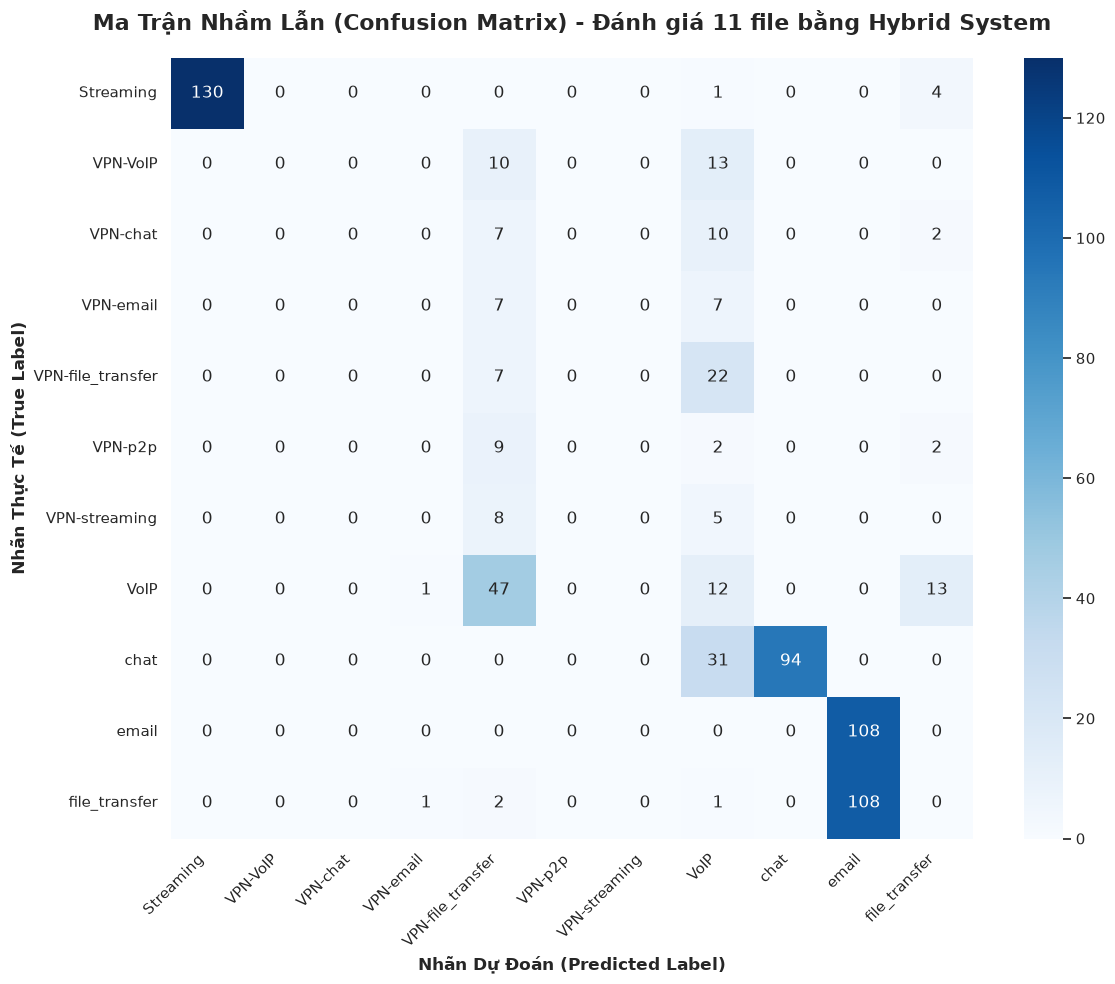

In [14]:
if 'df_eval' in locals() and not df_eval.empty:
    labels = sorted(list(set(y_true).union(set(y_pred))))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

    plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix) - Đánh giá 11 file bằng Hybrid System', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Nhãn Dự Đoán (Predicted Label)', fontsize=12, fontweight='bold')
    plt.ylabel('Nhãn Thực Tế (True Label)', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    # Lưu ảnh
    plt.savefig("Confusion_Matrix_Full_11_Classes.png", dpi=300)
    plt.show()